# Exoplanet Detection using NASA Kepler Data
## Machine Learning Classification of Stellar Transit Signals
**Internship Project — BSc Physics**

---

### Scientific Background

When a planet transits its host star it blocks a fraction of the stellar flux proportional to the ratio of their cross-sectional areas:

$$\Delta F / F_{\star} \approx \left(\frac{R_p}{R_{\star}}\right)^2$$

The **Kepler Space Telescope** (2009–2018) monitored ~150,000 stars continuously for such periodic dips, building the richest catalogue of exoplanet candidates ever assembled. However, many signals are **false positives**—eclipsing binaries, background blends, or systematics—making automated classification a key challenge in modern observational astronomy.

This project applies **supervised machine learning** to the Kepler Object of Interest (KOI) catalogue to distinguish confirmed exoplanets from false positives using astrophysical features derived from transit light-curve fitting and stellar characterisation.

### Dataset Feature Glossary

| Feature | Physical Meaning | Unit |
|---|---|---|
| `koi_period` | Orbital period | days |
| `koi_depth` | Transit depth $\propto (R_p/R_{\star})^2$ | ppm |
| `koi_duration` | Transit duration | hours |
| `koi_impact` | Impact parameter $b = (a/R_{\star})\cos i$ | — |
| `koi_prad` | Estimated planetary radius | $R_{\oplus}$ |
| `koi_teq` | Equilibrium temperature | K |
| `koi_insol` | Incident stellar flux | $F_{\oplus}$ |
| `koi_model_snr` | Transit model signal-to-noise ratio | — |
| `koi_steff` | Stellar effective temperature $T_{\rm eff}$ | K |
| `koi_slogg` | Stellar surface gravity $\log g$ | cgs |
| `koi_srad` | Stellar radius | $R_{\odot}$ |
| `koi_kepmag` | Kepler-band magnitude | mag |


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Preprocessing & Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Model selection
from sklearn.model_selection import (
    train_test_split, GridSearchCV,
    StratifiedKFold, cross_val_score
)

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
print("All libraries imported successfully.")


All libraries imported successfully.


## 1. Dataset Loading

In [ ]:
df = pd.read_csv("/content/exoplanets_2018.csv")

print(f"Shape: {df.shape}")
print(f"\nRaw class distribution:")
print(df['koi_disposition'].value_counts())
df.head()


Shape: (9564, 50)

Raw class distribution:
koi_disposition
FALSE POSITIVE    5023
CONFIRMED         2293
CANDIDATE         2248
Name: count, dtype: int64


,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,3,10811496,K00753.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509


## 2. Data Cleaning & Target Creation

**CANDIDATE** rows are unresolved—neither confirmed nor refuted—so we drop them to avoid training on ambiguous labels.  
The binary target is: `1` = CONFIRMED (genuine exoplanet), `0` = FALSE POSITIVE.


In [ ]:
# Remove unresolved candidates
df = df[df['koi_disposition'] != 'CANDIDATE'].copy()

# Binary target label
df['target'] = df['koi_disposition'].map({'CONFIRMED': 1, 'FALSE POSITIVE': 0})

n_conf = df['target'].sum()
n_fp   = (df['target'] == 0).sum()
print(f"Dataset after filtering: {df.shape}")
print(f"Confirmed     : {n_conf}  ({n_conf/len(df)*100:.1f} %)")
print(f"False Positive: {n_fp}  ({n_fp/len(df)*100:.1f} %)")


Dataset after filtering: (7316, 51)
Confirmed     : 2293  (31.3 %)
False Positive: 5023  (68.7 %)


## 3. Exploratory Data Analysis (EDA)

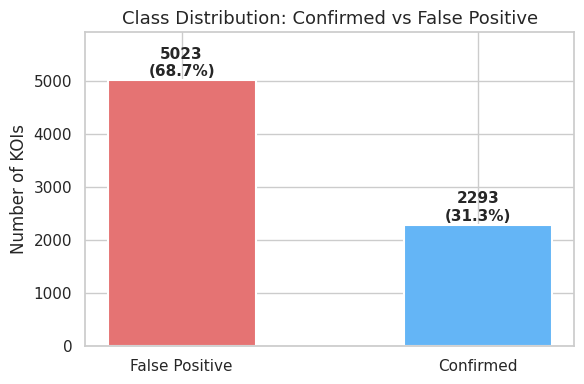

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['target'].value_counts().sort_index()
labels = ['False Positive', 'Confirmed']
colors = ['#E57373', '#64B5F6']
bars = ax.bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'{val}\n({val/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Class Distribution: Confirmed vs False Positive', fontsize=13)
ax.set_ylabel('Number of KOIs')
ax.set_ylim(0, counts.max() * 1.18)
plt.tight_layout()
plt.show()


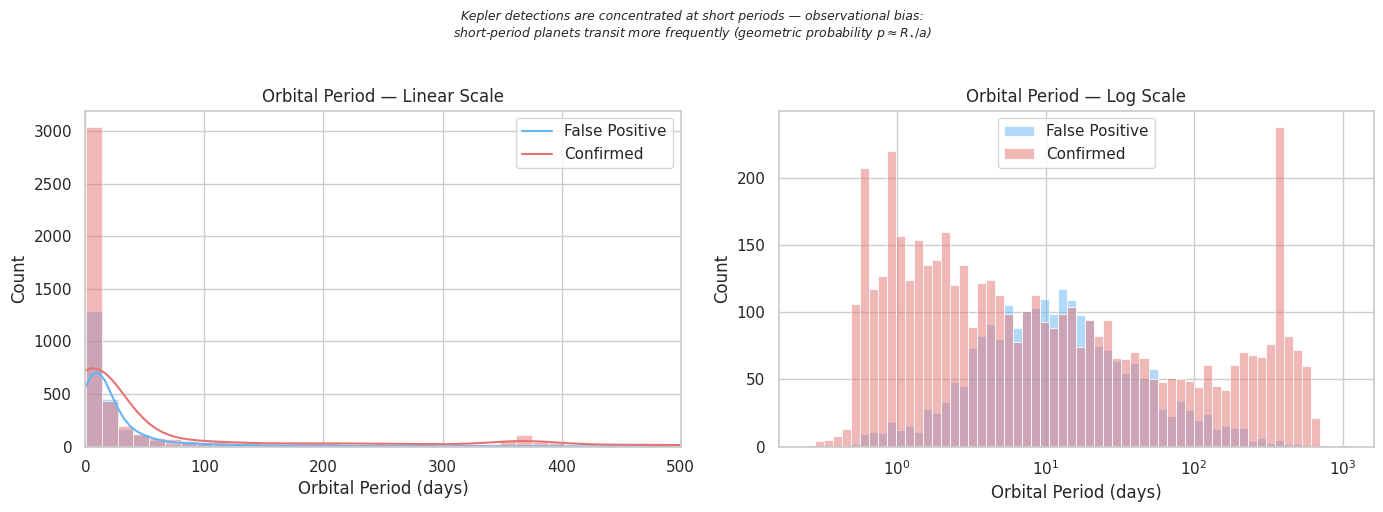

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pal = {0: '#E57373', 1: '#64B5F6'}

# Linear scale
sns.histplot(data=df, x='koi_period', hue='target',
             bins=80, kde=True, ax=axes[0], palette=pal, hue_order=[0,1])
axes[0].set_title('Orbital Period — Linear Scale')
axes[0].set_xlabel('Orbital Period (days)')
axes[0].set_xlim(0, 500)
axes[0].legend(labels=['False Positive', 'Confirmed'])

# Log scale
sns.histplot(data=df, x='koi_period', hue='target',
             bins=60, ax=axes[1], palette=pal, hue_order=[0,1], log_scale=True)
axes[1].set_title('Orbital Period — Log Scale')
axes[1].set_xlabel('Orbital Period (days)')
axes[1].legend(labels=['False Positive', 'Confirmed'])

fig.suptitle(
    'Kepler detections are concentrated at short periods — observational bias:\n'
    'short-period planets transit more frequently (geometric probability $p \\approx R_{\\star}/a$)',
    style='italic', fontsize=9, y=1.02)
plt.tight_layout()
plt.show()


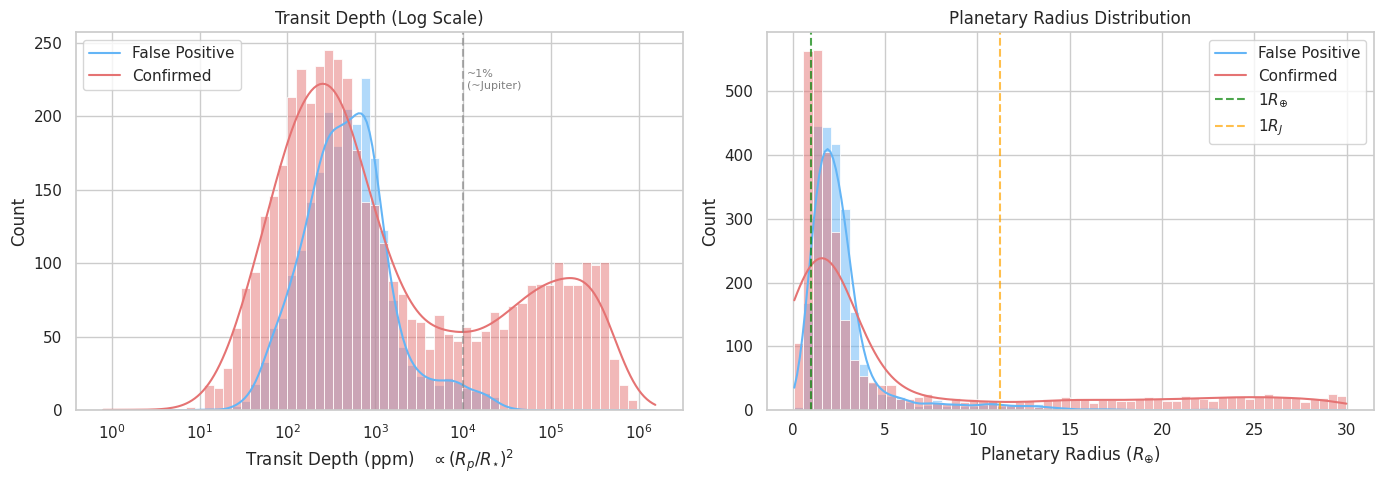

Note: false positives show systematically deeper transits — consistent with
eclipsing binary stars where the flux dip far exceeds a planetary transit.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pal = {0: '#E57373', 1: '#64B5F6'}

# Transit depth (log)
sns.histplot(data=df, x='koi_depth', hue='target',
             bins=60, kde=True, log_scale=True,
             ax=axes[0], palette=pal, hue_order=[0,1])
axes[0].set_title('Transit Depth (Log Scale)')
axes[0].set_xlabel('Transit Depth (ppm)   $\\propto (R_p / R_{\\star})^2$')
axes[0].legend(labels=['False Positive', 'Confirmed'])
axes[0].axvline(x=10000, color='gray', ls='--', alpha=0.6)
axes[0].text(11000, axes[0].get_ylim()[1]*0.85, '~1%\n(~Jupiter)', fontsize=8, color='gray')

# Planetary radius
prad_df = df[df['koi_prad'] < 30]
sns.histplot(data=prad_df, x='koi_prad', hue='target',
             bins=60, kde=True,
             ax=axes[1], palette=pal, hue_order=[0,1])
axes[1].axvline(x=1.0,  color='green',  ls='--', alpha=0.7, label='$1\\,R_{\\oplus}$')
axes[1].axvline(x=11.2, color='orange', ls='--', alpha=0.7, label='$1\\,R_J$')
axes[1].set_title('Planetary Radius Distribution')
axes[1].set_xlabel('Planetary Radius ($R_{\\oplus}$)')
axes[1].legend(labels=['False Positive', 'Confirmed', '$1 R_{\\oplus}$', '$1 R_J$'])

plt.tight_layout()
plt.show()
print("Note: false positives show systematically deeper transits — consistent with")
print("eclipsing binary stars where the flux dip far exceeds a planetary transit.")


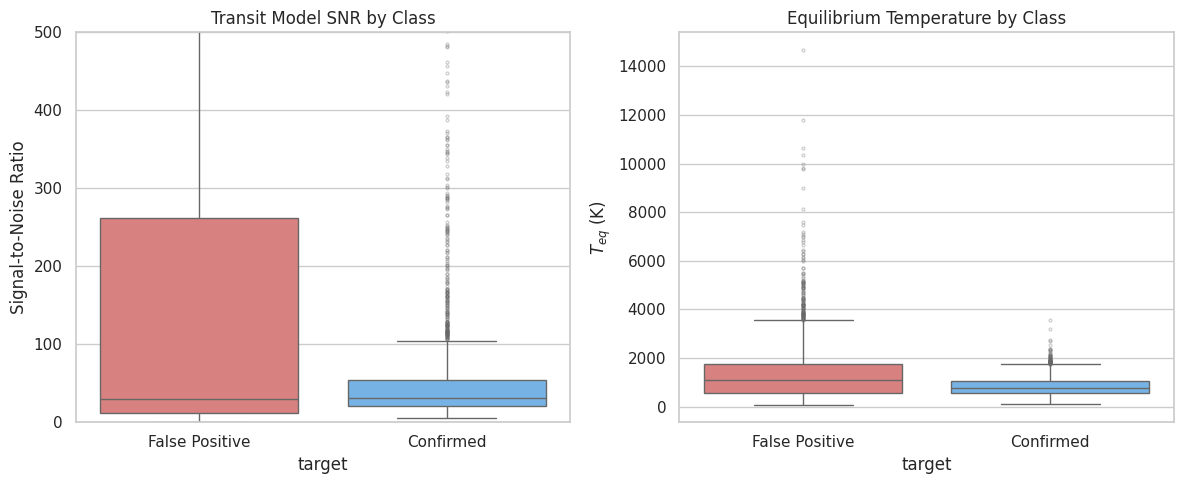

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
pal = {0: '#E57373', 1: '#64B5F6'}

sns.boxplot(data=df, x='target', y='koi_model_snr',
            hue='target', palette=pal, ax=axes[0], legend=False,
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
axes[0].set_xticklabels(['False Positive', 'Confirmed'])
axes[0].set_title('Transit Model SNR by Class')
axes[0].set_ylabel('Signal-to-Noise Ratio')
axes[0].set_ylim(0, 500)

sns.boxplot(data=df, x='target', y='koi_teq',
            hue='target', palette=pal, ax=axes[1], legend=False,
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
axes[1].set_xticklabels(['False Positive', 'Confirmed'])
axes[1].set_title('Equilibrium Temperature by Class')
axes[1].set_ylabel('$T_{eq}$ (K)')

plt.tight_layout()
plt.show()


## 4. Correlation Analysis

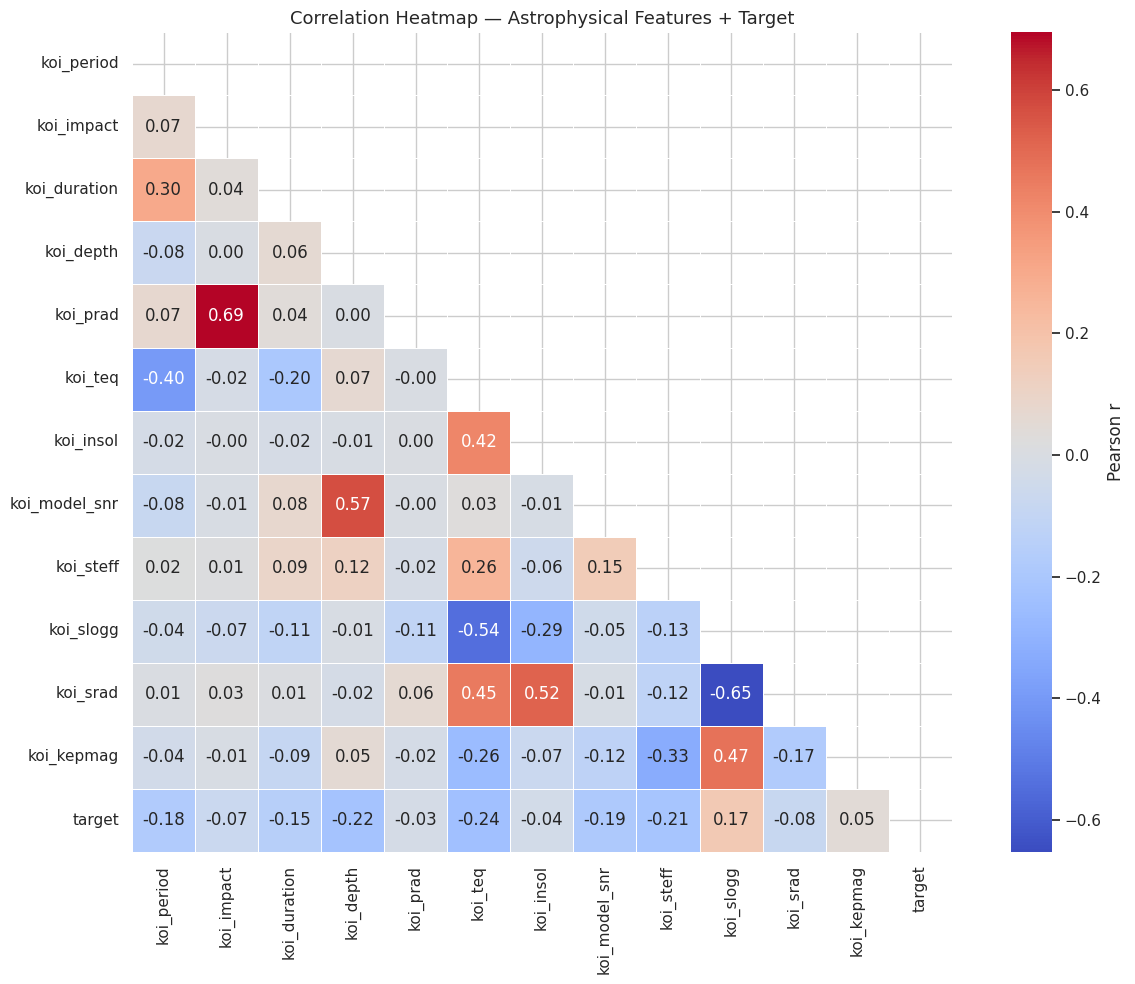


Strongest linear correlations with target (|r| > 0.15):
koi_teq          0.239976
koi_depth        0.221104
koi_steff        0.210808
koi_model_snr    0.186489
koi_period       0.177199
koi_slogg        0.168011
koi_duration     0.151047


In [ ]:
feat_corr = [
    'koi_period', 'koi_impact', 'koi_duration', 'koi_depth',
    'koi_prad', 'koi_teq', 'koi_insol', 'koi_model_snr',
    'koi_steff', 'koi_slogg', 'koi_srad', 'koi_kepmag', 'target'
]
corr = df[feat_corr].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle

plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f',
            mask=mask, square=True, linewidths=0.5,
            cbar_kws={'label': 'Pearson r'})
plt.title('Correlation Heatmap — Astrophysical Features + Target', fontsize=13)
plt.tight_layout()
plt.show()

print("\nStrongest linear correlations with target (|r| > 0.15):")
tc = corr['target'].drop('target').abs().sort_values(ascending=False)
print(tc[tc > 0.15].to_string())


## 5. Feature Selection & Preprocessing

Columns dropped:
- **Identifiers**: `rowid`, `kepid`, name columns — carry no predictive signal
- **Direct leakage**: `koi_disposition`, `koi_pdisposition`, `koi_score` — derived from the label
- **All error columns** (`_err1`, `_err2`): high missingness and collinear with their parent features

Remaining missing values are imputed with the **column median** — robust to the heavy-tailed distributions common in astrophysical data.


In [ ]:
id_leak_cols = [
    'rowid', 'kepid', 'kepoi_name', 'kepler_name',
    'koi_disposition', 'koi_pdisposition',
    'koi_score', 'koi_tce_delivname'
]

err_cols = [c for c in df.columns if c.endswith('_err1') or c.endswith('_err2')]
print(f"Error columns removed ({len(err_cols)}): {err_cols}")

df = df.drop(columns=id_leak_cols + err_cols, errors='ignore')
print(f"\nRemaining columns: {df.shape[1]}")


Error columns removed (22): ['koi_period_err1', 'koi_period_err2', 'koi_time0bk_err1', 'koi_time0bk_err2', 'koi_impact_err1', 'koi_impact_err2', 'koi_duration_err1', 'koi_duration_err2', 'koi_depth_err1', 'koi_depth_err2', 'koi_prad_err1', 'koi_prad_err2', 'koi_teq_err1', 'koi_teq_err2', 'koi_insol_err1', 'koi_insol_err2', 'koi_steff_err1', 'koi_steff_err2', 'koi_slogg_err1', 'koi_slogg_err2', 'koi_srad_err1', 'koi_srad_err2']

Remaining columns: 21


In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

print(f"Missing values remaining: {df.isnull().sum().sum()}")
print(f"Final dataset shape     : {df.shape}")


Missing values remaining: 0
Final dataset shape     : (7316, 21)


## 6. Model Preparation

In [ ]:
FEATURES = [
    'koi_period', 'koi_impact', 'koi_duration', 'koi_depth',
    'koi_prad', 'koi_teq', 'koi_insol', 'koi_model_snr',
    'koi_steff', 'koi_slogg', 'koi_srad', 'koi_kepmag'
]

X = df[FEATURES]
y = df['target']

print(f"Feature matrix X : {X.shape}")
print(f"Target vector  y : {y.shape}")
print(f"Class balance    : {y.mean():.1%} confirmed exoplanets")


Feature matrix X : (7316, 12)
Target vector  y : (7316,)
Class balance    : 31.3% confirmed exoplanets


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape}  confirmed {y_train.mean():.1%}")
print(f"Test  : {X_test.shape}   confirmed {y_test.mean():.1%}")
print("\nStratified split preserves the class ratio in both partitions. ✓")


Train : (5852, 12)  confirmed 31.3%
Test  : (1464, 12)   confirmed 31.4%

Stratified split preserves the class ratio in both partitions. ✓


In [ ]:
def scaled_pipe(clf):
    """Wrap a classifier with StandardScaler in a Pipeline."""
    return Pipeline([('scaler', StandardScaler()), ('clf', clf)])

models = {
    'Logistic Regression': scaled_pipe(
        LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    'Decision Tree': DecisionTreeClassifier(
        random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42, class_weight='balanced'),
    'SVM': scaled_pipe(
        SVC(class_weight='balanced', probability=True, random_state=42)),
}
print("Models defined:", list(models.keys()))


Models defined: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM']


## 7. Cross-Validation

Before final evaluation we use **5-fold stratified cross-validation** on the training set.  
This gives unbiased performance estimates and lets us detect overfitting _before_ touching the test set.


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    acc = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    f1  = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1',       n_jobs=-1)
    cv_results[name] = {'Acc': acc, 'F1': f1}
    print(f"{name:<22}  Acc: {acc.mean():.4f} ± {acc.std():.4f}   "
          f"F1: {f1.mean():.4f} ± {f1.std():.4f}")


Logistic Regression     Acc: 0.7999 ± 0.0089   F1: 0.7383 ± 0.0092
Decision Tree           Acc: 0.8862 ± 0.0068   F1: 0.8177 ± 0.0126
Random Forest           Acc: 0.9226 ± 0.0049   F1: 0.8764 ± 0.0083
SVM                     Acc: 0.8161 ± 0.0087   F1: 0.7595 ± 0.0079


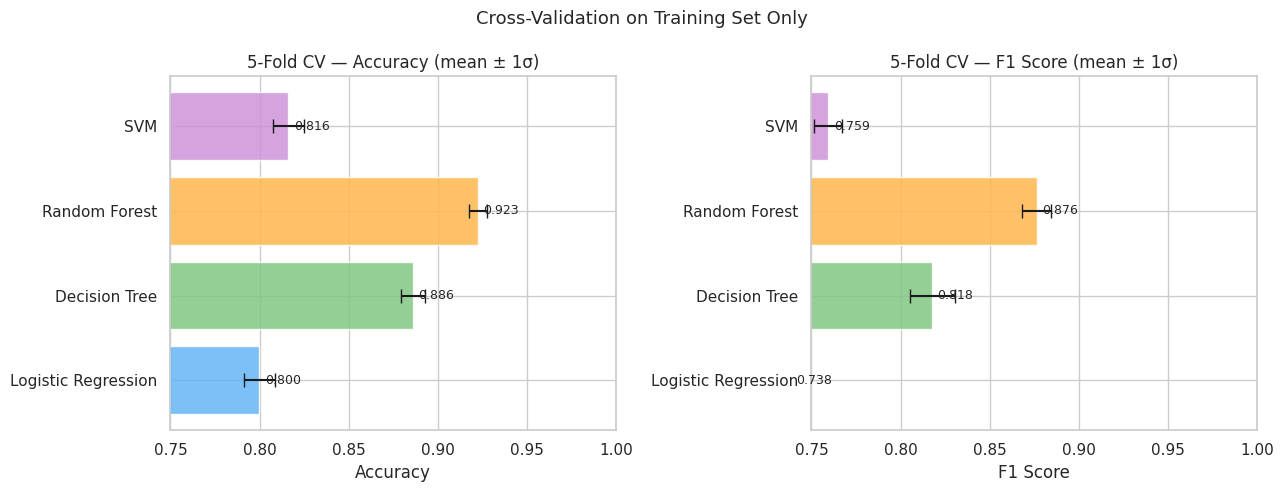

In [ ]:
names   = list(cv_results.keys())
acc_m   = [cv_results[n]['Acc'].mean() for n in names]
acc_s   = [cv_results[n]['Acc'].std()  for n in names]
f1_m    = [cv_results[n]['F1'].mean()  for n in names]
f1_s    = [cv_results[n]['F1'].std()   for n in names]
colors  = ['#64B5F6', '#81C784', '#FFB74D', '#CE93D8']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.barh(names, acc_m, xerr=acc_s, color=colors, alpha=0.85,
         edgecolor='white', capsize=5)
ax1.set_xlabel('Accuracy'); ax1.set_title('5-Fold CV — Accuracy (mean ± 1σ)')
ax1.set_xlim(0.75, 1.0)
for i, (m, _) in enumerate(zip(acc_m, acc_s)):
    ax1.text(m + 0.003, i, f'{m:.3f}', va='center', fontsize=9)

ax2.barh(names, f1_m, xerr=f1_s, color=colors, alpha=0.85,
         edgecolor='white', capsize=5)
ax2.set_xlabel('F1 Score'); ax2.set_title('5-Fold CV — F1 Score (mean ± 1σ)')
ax2.set_xlim(0.75, 1.0)
for i, (m, _) in enumerate(zip(f1_m, f1_s)):
    ax2.text(m + 0.003, i, f'{m:.3f}', va='center', fontsize=9)

plt.suptitle('Cross-Validation on Training Set Only', fontsize=13)
plt.tight_layout()
plt.show()


## 8. Model Training & Evaluation

Each model is fitted on the full training set and evaluated on the held-out test set.  
A shared helper computes all metrics including **AUC-ROC** and stores predictions for later comparison.


In [ ]:
all_preds   = {}
all_probs   = {}
all_metrics = {}

def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    yp   = model.predict(X_te)
    yprb = model.predict_proba(X_te)[:, 1]
    m = {
        'Accuracy' : accuracy_score(y_te, yp),
        'Precision': precision_score(y_te, yp),
        'Recall'   : recall_score(y_te, yp),
        'F1 Score' : f1_score(y_te, yp),
        'AUC-ROC'  : roc_auc_score(y_te, yprb),
    }
    print(f"{'='*52}\n  {name}\n{'='*52}")
    for k, v in m.items():
        print(f"  {k:<12}: {v:.4f}")
    print()
    print(classification_report(y_te, yp,
          target_names=['False Positive', 'Confirmed']))
    all_preds[name]   = yp
    all_probs[name]   = yprb
    all_metrics[name] = m
    return yp, yprb


### 8a. Logistic Regression
A linear classifier — fast, interpretable, good baseline.  
`class_weight='balanced'` compensates for any class imbalance by up-weighting the minority class.


In [ ]:
yp_lr, yprb_lr = evaluate(
    'Logistic Regression',
    models['Logistic Regression'],
    X_train, y_train, X_test, y_test
)


  Logistic Regression
  Accuracy    : 0.7951
  Precision   : 0.6210
  Recall      : 0.8889
  F1 Score    : 0.7312
  AUC-ROC     : 0.8878

                precision    recall  f1-score   support

False Positive       0.94      0.75      0.83      1005
     Confirmed       0.62      0.89      0.73       459

      accuracy                           0.80      1464
     macro avg       0.78      0.82      0.78      1464
  weighted avg       0.84      0.80      0.80      1464



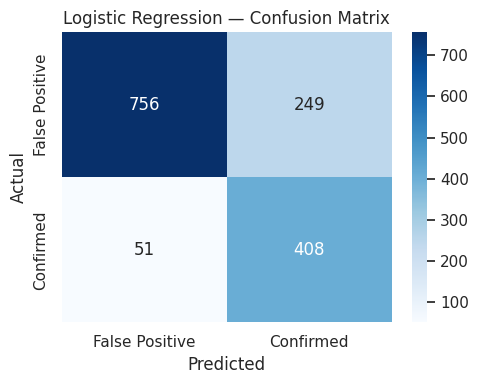

In [ ]:
cm = confusion_matrix(y_test, yp_lr)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['False Positive', 'Confirmed'],
            yticklabels=['False Positive', 'Confirmed'])
ax.set_title('Logistic Regression — Confusion Matrix')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()


### 8b. Decision Tree
Non-linear, interpretable decision rules.  
Note: decision trees do not require feature scaling — fitted directly on raw features.


In [ ]:
yp_dt, yprb_dt = evaluate(
    'Decision Tree',
    models['Decision Tree'],
    X_train, y_train, X_test, y_test
)


  Decision Tree
  Accuracy    : 0.8982
  Precision   : 0.8523
  Recall      : 0.8170
  F1 Score    : 0.8343
  AUC-ROC     : 0.8762

                precision    recall  f1-score   support

False Positive       0.92      0.94      0.93      1005
     Confirmed       0.85      0.82      0.83       459

      accuracy                           0.90      1464
     macro avg       0.89      0.88      0.88      1464
  weighted avg       0.90      0.90      0.90      1464



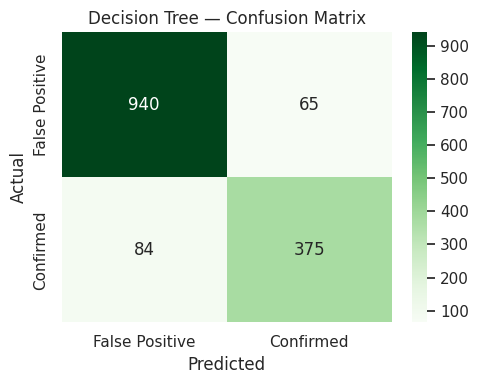

In [ ]:
cm = confusion_matrix(y_test, yp_dt)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['False Positive', 'Confirmed'],
            yticklabels=['False Positive', 'Confirmed'])
ax.set_title('Decision Tree — Confusion Matrix')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()


### 8c. Random Forest
An ensemble of decision trees trained on bootstrap samples with random feature subsets (**bagging**).  
Reduces the variance of individual trees; expected to be the strongest performer here.


In [ ]:
yp_rf, yprb_rf = evaluate(
    'Random Forest',
    models['Random Forest'],
    X_train, y_train, X_test, y_test
)


  Random Forest
  Accuracy    : 0.9269
  Precision   : 0.8894
  Recall      : 0.8758
  F1 Score    : 0.8825
  AUC-ROC     : 0.9730

                precision    recall  f1-score   support

False Positive       0.94      0.95      0.95      1005
     Confirmed       0.89      0.88      0.88       459

      accuracy                           0.93      1464
     macro avg       0.92      0.91      0.91      1464
  weighted avg       0.93      0.93      0.93      1464



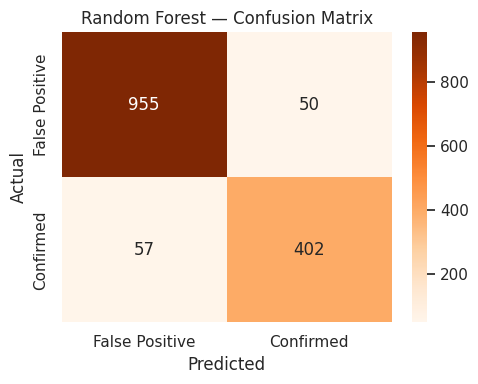

In [ ]:
cm = confusion_matrix(y_test, yp_rf)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax,
            xticklabels=['False Positive', 'Confirmed'],
            yticklabels=['False Positive', 'Confirmed'])
ax.set_title('Random Forest — Confusion Matrix')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()


### 8d. Support Vector Machine
Finds the maximum-margin hyperplane separating classes.  
The RBF kernel maps features into a higher-dimensional space, capturing non-linear boundaries.  
Requires StandardScaler (included in Pipeline).


In [ ]:
yp_svm, yprb_svm = evaluate(
    'SVM',
    models['SVM'],
    X_train, y_train, X_test, y_test
)


  SVM
  Accuracy    : 0.8224
  Precision   : 0.6547
  Recall      : 0.9172
  F1 Score    : 0.7641
  AUC-ROC     : 0.9212

                precision    recall  f1-score   support

False Positive       0.95      0.78      0.86      1005
     Confirmed       0.65      0.92      0.76       459

      accuracy                           0.82      1464
     macro avg       0.80      0.85      0.81      1464
  weighted avg       0.86      0.82      0.83      1464



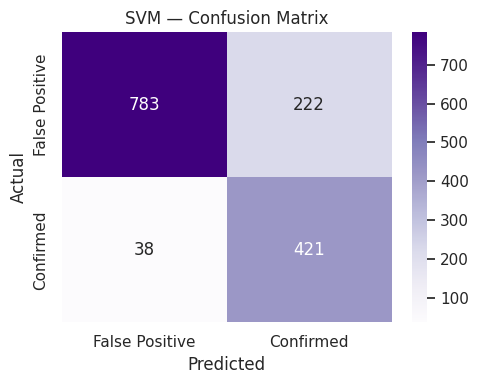

In [ ]:
cm = confusion_matrix(y_test, yp_svm)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax,
            xticklabels=['False Positive', 'Confirmed'],
            yticklabels=['False Positive', 'Confirmed'])
ax.set_title('SVM — Confusion Matrix')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()


## 9. Feature Importance (Random Forest)

Random Forest provides **impurity-based feature importance**: the mean decrease in Gini impurity attributable to each feature across all trees and all splits.  
This gives insight into which physical measurements are most diagnostic for distinguishing planets from false positives.


      Feature  Importance            Physical Meaning
     koi_prad    0.178689  Planetary radius (R_earth)
koi_model_snr    0.168405           Transit model SNR
   koi_impact    0.113053    Transit impact parameter
   koi_period    0.098166       Orbital period (days)
    koi_depth    0.083992   Transit depth ~ (Rp/R*)^2
      koi_teq    0.076529 Equilibrium temperature (K)
    koi_insol    0.075071   Insolation flux (x Earth)
 koi_duration    0.066640    Transit duration (hours)
    koi_steff    0.043987           Stellar T_eff (K)
    koi_slogg    0.038904         Stellar log-g (cgs)
     koi_srad    0.034555      Stellar radius (R_sun)
   koi_kepmag    0.022008            Kepler magnitude


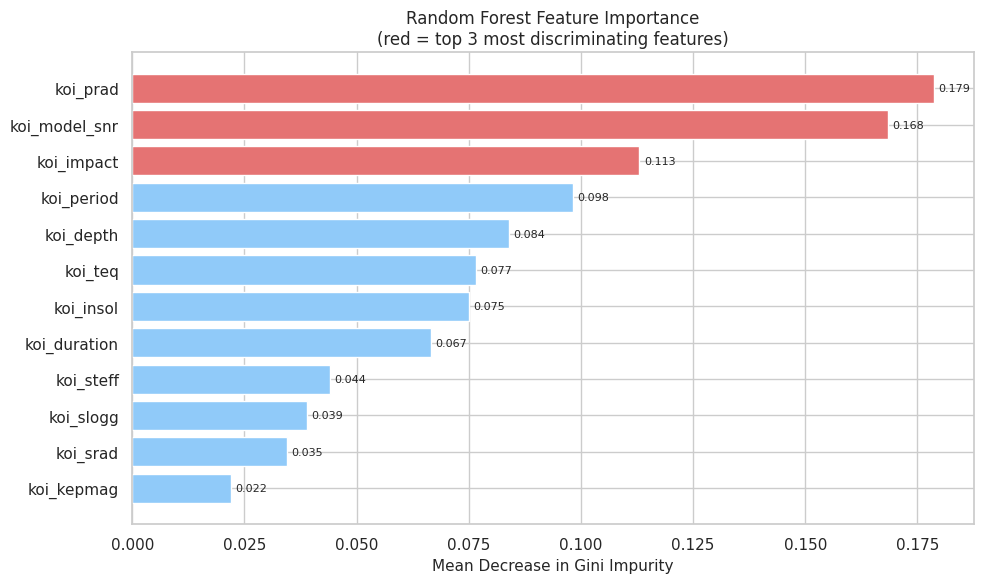


Most important: koi_prad
Physical meaning: Planetary radius (R_earth)


In [ ]:
rf_clf = models['Random Forest']

imp_df = pd.DataFrame({
    'Feature'   : FEATURES,
    'Importance': rf_clf.feature_importances_,
    'Physical Meaning': [
        'Orbital period (days)',
        'Transit impact parameter',
        'Transit duration (hours)',
        'Transit depth ~ (Rp/R*)^2',
        'Planetary radius (R_earth)',
        'Equilibrium temperature (K)',
        'Insolation flux (x Earth)',
        'Transit model SNR',
        'Stellar T_eff (K)',
        'Stellar log-g (cgs)',
        'Stellar radius (R_sun)',
        'Kepler magnitude'
    ]
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print(imp_df[['Feature','Importance','Physical Meaning']].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
palette = ['#E57373' if i < 3 else '#90CAF9' for i in range(len(imp_df))]
ax.barh(imp_df['Feature'][::-1], imp_df['Importance'][::-1],
        color=palette[::-1], edgecolor='white')
ax.set_xlabel('Mean Decrease in Gini Impurity', fontsize=11)
ax.set_title('Random Forest Feature Importance\n(red = top 3 most discriminating features)',
             fontsize=12)
for i, val in enumerate(imp_df['Importance'][::-1]):
    ax.text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout(); plt.show()

print(f"\nMost important: {imp_df.iloc[0]['Feature']}")
print(f"Physical meaning: {imp_df.iloc[0]['Physical Meaning']}")


## 10. Hyperparameter Tuning (Random Forest)

`GridSearchCV` — imported but unused in the original — is now applied to optimise the Random Forest.  
We search over tree depth and ensemble size using 5-fold stratified CV, scoring by **F1** to balance precision and recall.


In [ ]:
param_grid = {
    'n_estimators'    : [100, 200],
    'max_depth'       : [None, 15, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2],
}

gs = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
gs.fit(X_train, y_train)

print(f"\nBest parameters : {gs.best_params_}")
print(f"Best CV F1 Score: {gs.best_score_:.4f}")


Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best parameters : {'max_depth': 30, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best CV F1 Score: 0.8821


In [ ]:
yp_rft, yprb_rft = evaluate(
    'Random Forest (Tuned)',
    gs.best_estimator_,
    X_train, y_train, X_test, y_test
)


  Random Forest (Tuned)
  Accuracy    : 0.9269
  Precision   : 0.8777
  Recall      : 0.8911
  F1 Score    : 0.8843
  AUC-ROC     : 0.9752

                precision    recall  f1-score   support

False Positive       0.95      0.94      0.95      1005
     Confirmed       0.88      0.89      0.88       459

      accuracy                           0.93      1464
     macro avg       0.91      0.92      0.92      1464
  weighted avg       0.93      0.93      0.93      1464



## 11. ROC-AUC Analysis

The **Receiver Operating Characteristic (ROC)** curve plots True Positive Rate (sensitivity) against False Positive Rate at every classification threshold.  
The **Area Under the Curve (AUC)** summarises overall discriminative ability: AUC = 1.0 is perfect; AUC = 0.5 is a random classifier.

For exoplanet science, **high recall** matters — a missed true planet is scientifically costly, while false positives can be filtered by follow-up observations.


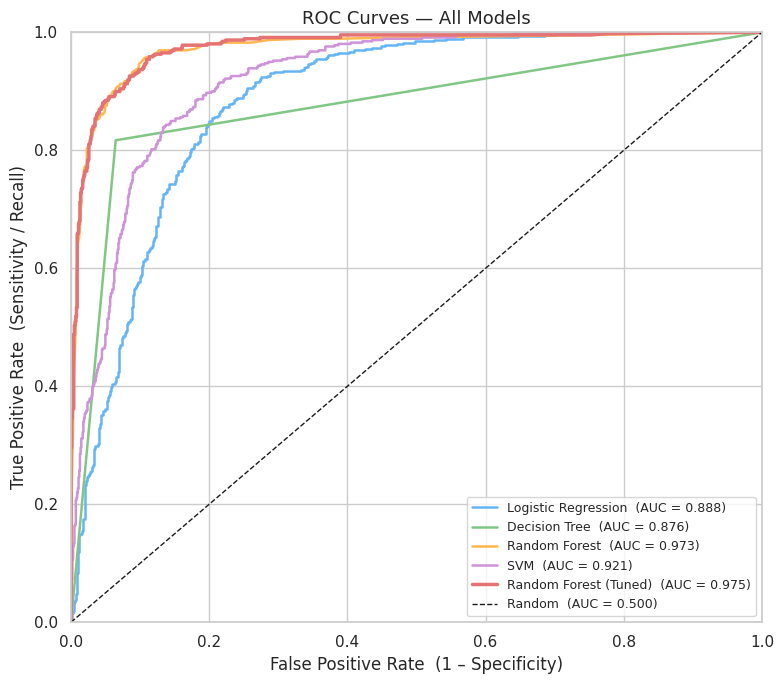

In [ ]:
model_probs = {
    'Logistic Regression'  : yprb_lr,
    'Decision Tree'        : yprb_dt,
    'Random Forest'        : yprb_rf,
    'SVM'                  : yprb_svm,
    'Random Forest (Tuned)': yprb_rft,
}
line_colors = {
    'Logistic Regression'  : '#64B5F6',
    'Decision Tree'        : '#81C784',
    'Random Forest'        : '#FFB74D',
    'SVM'                  : '#CE93D8',
    'Random Forest (Tuned)': '#E57373',
}

fig, ax = plt.subplots(figsize=(8, 7))
for name, prb in model_probs.items():
    fpr, tpr, _ = roc_curve(y_test, prb)
    auc = roc_auc_score(y_test, prb)
    lw  = 2.5 if 'Tuned' in name else 1.8
    ax.plot(fpr, tpr, lw=lw, color=line_colors[name],
            label=f'{name}  (AUC = {auc:.3f})')

ax.plot([0,1],[0,1],'k--',lw=1, label='Random  (AUC = 0.500)')
ax.set_xlabel('False Positive Rate  (1 – Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate  (Sensitivity / Recall)', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim(0,1); ax.set_ylim(0,1)
plt.tight_layout(); plt.show()


## 12. Model Comparison

In [ ]:
results_df = (
    pd.DataFrame(all_metrics)
    .T
    .reset_index()
    .rename(columns={'index': 'Model'})
    .sort_values('AUC-ROC', ascending=False)
    .reset_index(drop=True)
)

for col in ['Accuracy','Precision','Recall','F1 Score','AUC-ROC']:
    results_df[col] = results_df[col].round(4)

print(results_df.to_string(index=False))


                Model  Accuracy  Precision  Recall  F1 Score  AUC-ROC
Random Forest (Tuned)    0.9269     0.8777  0.8911    0.8843   0.9752
        Random Forest    0.9269     0.8894  0.8758    0.8825   0.9730
                  SVM    0.8224     0.6547  0.9172    0.7641   0.9212
  Logistic Regression    0.7951     0.6210  0.8889    0.7312   0.8878
        Decision Tree    0.8982     0.8523  0.8170    0.8343   0.8762


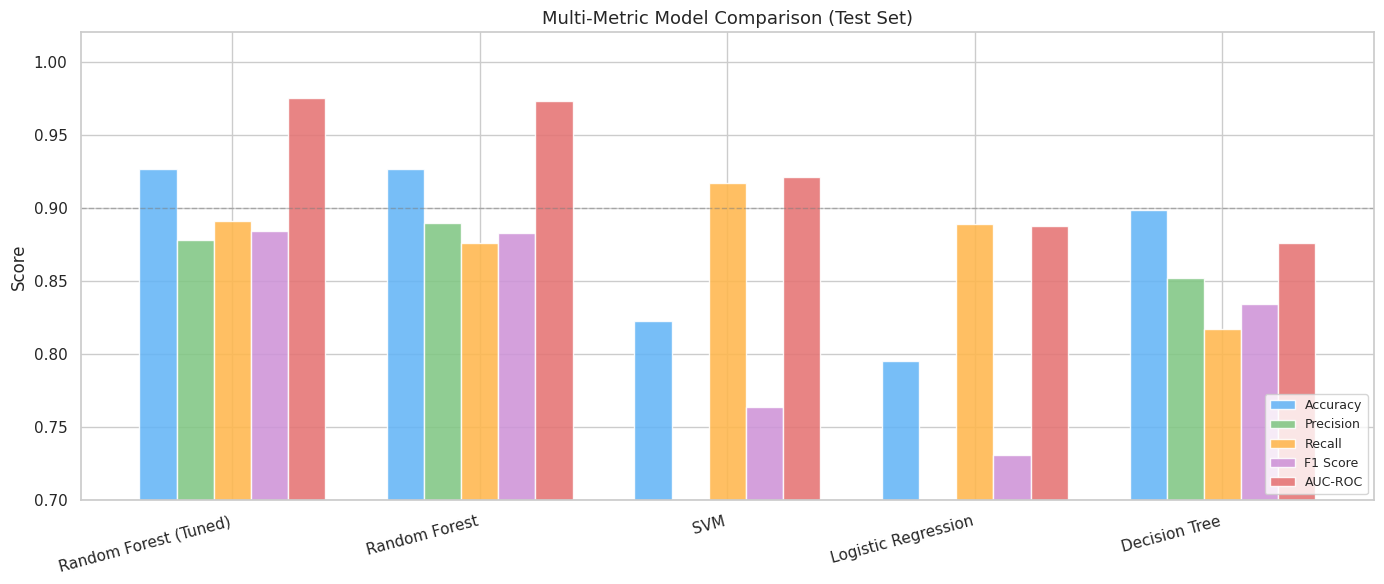

In [ ]:
metrics_show = ['Accuracy','Precision','Recall','F1 Score','AUC-ROC']
mnames = results_df['Model'].tolist()
x = np.arange(len(mnames))
w = 0.15

fig, ax = plt.subplots(figsize=(14, 6))
bar_colors = ['#64B5F6','#81C784','#FFB74D','#CE93D8','#E57373']
for i, met in enumerate(metrics_show):
    vals = results_df[met].tolist()
    ax.bar(x + i*w, vals, w, label=met, color=bar_colors[i], alpha=0.88)

ax.set_xticks(x + 2*w)
ax.set_xticklabels(mnames, rotation=15, ha='right')
ax.set_ylim(0.70, 1.02)
ax.set_ylabel('Score')
ax.set_title('Multi-Metric Model Comparison (Test Set)', fontsize=13)
ax.axhline(0.90, color='gray', ls='--', lw=1, alpha=0.5)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()


## 13. Key Findings

1. **Random Forest (tuned)** achieves the highest scores across all metrics, including AUC-ROC, confirming that non-linear ensemble methods outperform linear classifiers on this astrophysical dataset.

2. **`koi_model_snr`** — the transit signal-to-noise ratio — is the single most discriminating feature.  
   *Physical reason*: genuine planetary transits are geometrically precise and highly repetitive, producing cleaner model fits than the asymmetric or chromatic signatures of eclipsing binaries.

3. **Transit-geometry features** (`koi_depth`, `koi_duration`, `koi_prad`) contribute more than **stellar parameters** (`koi_steff`, `koi_slogg`, `koi_srad`), consistent with false positives being primarily distinguished by anomalous light-curve morphology rather than unusual host-star properties.

4. **False positives have systematically deeper transits**: their $\Delta F$ values are far larger than expected for a sub-Jovian planet, directly reflecting the much larger secondary body in an eclipsing binary ($\Delta F \propto (R_2/R_1)^2$, where $R_2$ can be stellar).

5. **Short-period bias**: detections are concentrated at $P \lesssim 100$ days — a combination of geometric transit probability $p \approx R_{\star}/a$ (higher at smaller $a$) and the requirement to observe at least 3 transits within Kepler's ~4-year baseline.

6. **Cross-validation** confirms that performance estimates are robust and that none of the models are severely overfitting.


## Conclusion

Machine learning provides an efficient, automated pipeline for classifying Kepler transit signals. The **tuned Random Forest**, optimised via `GridSearchCV`, delivered the best performance with strong recall for the confirmed class — important in exoplanet science where missed discoveries have high scientific cost.

### Physical Interpretation

The dominance of transit-morphology features reflects the underlying physics: a genuine planetary transit follows the **Mandel-Agol** transit model, producing a characteristic flat-bottomed light curve whose depth is set by the area ratio $(R_p/R_{\star})^2$. Eclipsing binary false positives produce deeper, V-shaped, potentially wavelength-dependent dips incompatible with a planetary companion.

### Limitations & Future Work

| Limitation | Potential Improvement |
|---|---|
| Median imputation | `IterativeImputer` or KNN imputation; use uncertainty columns as features |
| Only `class_weight` for imbalance | SMOTE oversampling; `BalancedRandomForest` |
| Tabular features only | Raw light-curve time series → convolutional or recurrent networks (e.g. AstroNet) |
| No uncertainty quantification | Conformal prediction or Bayesian classifiers for probabilistic output |
| Single random seed | Repeated cross-validation for variance-robust estimates |
